In [29]:
# ============================================
# Standard library imports
# ============================================

import sys
import re
import ast
import logging
import warnings
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================
# Numeric / statistics
# ============================================

import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import spearmanr, pearsonr


# ============================================
# Plotting / visualization
# ============================================

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import seaborn as sns


# ============================================
# Version info
# ============================================

print(f"python  = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas  = {pd.__version__}")
print(f"numpy   = {np.__version__}")
print(f"scipy   = {scipy.__version__}")


# ============================================
# Logging
# ============================================

logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python  = 3.11.15
pandas  = 2.3.3
numpy   = 2.4.6
scipy   = 1.17.1


In [30]:
# ============================================
# Analysis configuration
# ============================================

RESULT_DIR = Path("../results")
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "table"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SPECIES_LIST = ["AT21", "NB21", "OS21"]

MODEL_INFO = {
    "lgbm": {
        "label": "LightGBM",
        "dir": RESULT_DIR / "lgbm",
        "color": "#913535FF",
    },
    "rf": {
        "label": "Random Forest",
        "dir": RESULT_DIR / "rf",
        "color": "#134956",
    },
}

DATASET_ORDER = ["Training", "Test"]

print("RESULT_DIR:", RESULT_DIR.resolve())
print("FIGURE_DIR:", FIGURE_DIR.resolve())
print("TABLE_DIR :", TABLE_DIR.resolve())

RESULT_DIR: /home/ha-ibnu/Code/regression/results
FIGURE_DIR: /home/ha-ibnu/Code/regression/results/figures
TABLE_DIR : /home/ha-ibnu/Code/regression/results/table


In [31]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=12,
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=12,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

In [32]:
# ============================================
# Statistical helper functions
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return spearmanr(x, y)


def summarize_numeric(df, group_cols, value_col):
    return (
        df
        .groupby(group_cols, dropna=False)[value_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

In [33]:
# ============================================
# Load saved Step 1 result tables
# ============================================

def load_result_table(model_key, suffix):
    model_dir = MODEL_INFO[model_key]["dir"]
    rows = []

    for species in SPECIES_LIST:
        file = model_dir / f"{species}.{model_key}.{suffix}.tsv"

        if not file.exists():
            logger.warning("Missing file: %s", file)
            continue

        df = pd.read_csv(file, sep="\t")
        rows.append(df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


metrics_df = pd.concat([
    load_result_table("lgbm", "metrics"),
    load_result_table("rf", "metrics"),
], ignore_index=True)

best_params_df = pd.concat([
    load_result_table("lgbm", "best_params"),
    load_result_table("rf", "best_params"),
], ignore_index=True)

feature_importance_df = pd.concat([
    load_result_table("lgbm", "feature_importance"),
    load_result_table("rf", "feature_importance"),
], ignore_index=True)

shap_summary_df = pd.concat([
    load_result_table("lgbm", "shap_summary"),
    load_result_table("rf", "shap_summary"),
], ignore_index=True)

cv_region_df = pd.concat([
    load_result_table("lgbm", "cv_by_region"),
    load_result_table("rf", "cv_by_region"),
], ignore_index=True)

cv_feature_type_df = pd.concat([
    load_result_table("lgbm", "cv_by_feature_type"),
    load_result_table("rf", "cv_by_feature_type"),
], ignore_index=True)

prediction_df = pd.concat([
    load_result_table("lgbm", "predictions"),
    load_result_table("rf", "predictions"),
], ignore_index=True)

# ============================================
# Quick sanity check
# ============================================

tables = {
    "metrics": metrics_df,
    "best_params": best_params_df,
    "feature_importance": feature_importance_df,
    "shap_summary": shap_summary_df,
    "cv_region": cv_region_df,
    "cv_feature_type": cv_feature_type_df,
    "prediction": prediction_df,
}

for name, df in tables.items():
    print(f"{name:20s}: {df.shape}")

display(metrics_df.head())
display(prediction_df.head())

metrics             : (12, 22)
best_params         : (6, 14)
feature_importance  : (2663, 5)
shap_summary        : (2782, 7)
cv_region           : (90, 16)
cv_feature_type     : (1530, 20)
prediction          : (36118, 9)


,species,model,dataset,R2,Pearson_r,RMSE,MAE,best_cv_R2,n_train,n_test,...,k_cv,n_estimators,learning_rate,best_param.max_depth,best_param.min_child_samples,best_param.feature_fraction,best_param.num_leaves,best_param.min_samples_leaf,best_param.min_samples_split,best_param.max_features
0,AT21,LightGBM,Training,0.559557,0.775263,0.663659,0.510021,0.250487,5698,1428,...,10,100,0.05,13,28.0,0.2,39.0,NaN,NaN,NaN
1,AT21,LightGBM,Test,0.291471,0.541506,0.846832,0.646462,0.250487,5698,1428,...,10,100,0.05,13,28.0,0.2,39.0,NaN,NaN,NaN
2,NB21,LightGBM,Training,0.604433,0.799720,0.628941,0.483723,0.309222,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
3,NB21,LightGBM,Test,0.294002,0.543576,0.855906,0.649270,0.309222,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
4,OS21,LightGBM,Training,0.703673,0.864441,0.544359,0.420133,0.361391,4445,1107,...,10,100,0.05,7,2.0,0.7,44.0,NaN,NaN,NaN


,species,model,var_id,trans_id,gene_id,dataset,observed,predicted,residual
0,AT21,LightGBM,AT5G05370.1.1591901.1590815,AT5G05370.1,AT5G05370,Training,0.054841,0.418203,-0.363362
1,AT21,LightGBM,AT5G16060.1.5246121.5247413,AT5G16060.1,AT5G16060,Training,-1.094430,-0.499050,-0.595380
2,AT21,LightGBM,AT2G34160.1.14426246.14427367,AT2G34160.1,AT2G34160,Training,-0.073162,-0.132563,0.059401
3,AT21,LightGBM,AT5G54600.1.22183004.22184509,AT5G54600.1,AT5G54600,Training,-0.302488,-0.542934,0.240445
4,AT21,LightGBM,AT2G23340.1.9937988.9938873,AT2G23340.1,AT2G23340,Training,1.491571,0.360980,1.130591


In [34]:
# ============================================
# EDA inventory of loaded result tables
# ============================================

for name, df in tables.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print()

    if "species" in df.columns:
        print("Species:")
        print(df["species"].value_counts(dropna=False))
        print()

    if "model" in df.columns:
        print("Models:")
        print(df["model"].value_counts(dropna=False))
        print()

    if "dataset" in df.columns:
        print("Datasets:")
        print(df["dataset"].value_counts(dropna=False))
        print()

    display(df.head())

metrics
Shape: (12, 22)
Columns:
['species', 'model', 'dataset', 'R2', 'Pearson_r', 'RMSE', 'MAE', 'best_cv_R2', 'n_train', 'n_test', 'n_features', 'n_trials', 'k_cv', 'n_estimators', 'learning_rate', 'best_param.max_depth', 'best_param.min_child_samples', 'best_param.feature_fraction', 'best_param.num_leaves', 'best_param.min_samples_leaf', 'best_param.min_samples_split', 'best_param.max_features']

Species:
species
AT21    4
NB21    4
OS21    4
Name: count, dtype: int64

Models:
model
LightGBM        6
RandomForest    6
Name: count, dtype: int64

Datasets:
dataset
Training    6
Test        6
Name: count, dtype: int64



,species,model,dataset,R2,Pearson_r,RMSE,MAE,best_cv_R2,n_train,n_test,...,k_cv,n_estimators,learning_rate,best_param.max_depth,best_param.min_child_samples,best_param.feature_fraction,best_param.num_leaves,best_param.min_samples_leaf,best_param.min_samples_split,best_param.max_features
0,AT21,LightGBM,Training,0.559557,0.775263,0.663659,0.510021,0.250487,5698,1428,...,10,100,0.05,13,28.0,0.2,39.0,NaN,NaN,NaN
1,AT21,LightGBM,Test,0.291471,0.541506,0.846832,0.646462,0.250487,5698,1428,...,10,100,0.05,13,28.0,0.2,39.0,NaN,NaN,NaN
2,NB21,LightGBM,Training,0.604433,0.799720,0.628941,0.483723,0.309222,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
3,NB21,LightGBM,Test,0.294002,0.543576,0.855906,0.649270,0.309222,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
4,OS21,LightGBM,Training,0.703673,0.864441,0.544359,0.420133,0.361391,4445,1107,...,10,100,0.05,7,2.0,0.7,44.0,NaN,NaN,NaN


best_params
Shape: (6, 14)
Columns:
['species', 'model', 'best_cv_R2', 'n_trials', 'k_cv', 'n_estimators', 'learning_rate', 'max_depth', 'min_child_samples', 'feature_fraction', 'num_leaves', 'min_samples_leaf', 'min_samples_split', 'max_features']

Species:
species
AT21    2
NB21    2
OS21    2
Name: count, dtype: int64

Models:
model
LightGBM        3
RandomForest    3
Name: count, dtype: int64



,species,model,best_cv_R2,n_trials,k_cv,n_estimators,learning_rate,max_depth,min_child_samples,feature_fraction,num_leaves,min_samples_leaf,min_samples_split,max_features
0,AT21,LightGBM,0.250487,20,10,100,0.05,13,28.0,0.2,39.0,NaN,NaN,NaN
1,NB21,LightGBM,0.309222,20,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
2,OS21,LightGBM,0.361391,20,10,100,0.05,7,2.0,0.7,44.0,NaN,NaN,NaN
3,AT21,RandomForest,0.254815,20,10,500,NaN,10,NaN,NaN,NaN,5.0,6.0,0.5
4,NB21,RandomForest,0.308769,20,10,500,NaN,10,NaN,NaN,NaN,1.0,11.0,0.5


feature_importance
Shape: (2663, 5)
Columns:
['species', 'model', 'rank', 'feature', 'importance']

Species:
species
OS21    891
AT21    890
NB21    882
Name: count, dtype: int64

Models:
model
RandomForest    1359
LightGBM        1304
Name: count, dtype: int64



...

,species,model,combo,combo_id,mean_R2,std_R2,median_R2,min_R2,max_R2,n_folds,n_sets,n_features,in_UTR5,in_CDS,in_UTR3,in_mRNA
0,AT21,LightGBM,mRNA,mRNA,0.221270,0.025036,0.223400,0.170793,0.267469,10,1,89,0,0,0,1
1,AT21,LightGBM,5'UTR,UTR5,0.218231,0.025472,0.213622,0.180787,0.266884,10,1,93,1,0,0,0
2,AT21,LightGBM,CDS,CDS,0.217519,0.039143,0.224926,0.138671,0.270327,10,1,190,0,1,0,0
3,AT21,LightGBM,3'UTR,UTR3,0.179362,0.027539,0.174337,0.125304,0.221459,10,1,92,0,0,1,0
4,AT21,LightGBM,5'UTR+CDS,UTR5+CDS,0.252983,0.037146,0.253476,0.180700,0.309201,10,2,283,1,1,0,0


cv_feature_type
Shape: (1530, 20)
Columns:
['species', 'model', 'combo', 'combo_id', 'mean_R2', 'std_R2', 'median_R2', 'min_R2', 'max_R2', 'n_folds', 'n_sets', 'n_features', 'in_Length', 'in_Nucleotide_kmer_freq', 'in_ORF_nonCDS', 'in_Codon_usage', 'in_Wobble', 'in_Amino_acid_composition', 'in_Dicodon', 'in_RNA_structure_MFE']

Species:
species
AT21    510
NB21    510
OS21    510
Name: count, dtype: int64

Models:
model
LightGBM        765
RandomForest    765
Name: count, dtype: int64



,species,model,combo,combo_id,mean_R2,std_R2,median_R2,min_R2,max_R2,n_folds,n_sets,n_features,in_Length,in_Nucleotide_kmer_freq,in_ORF_nonCDS,in_Codon_usage,in_Wobble,in_Amino_acid_composition,in_Dicodon,in_RNA_structure_MFE
0,AT21,LightGBM,Nucleotide_kmer_freq,Nucleotide_kmer_freq,0.244605,0.033274,0.242689,0.192148,0.308778,10,1,345,0,1,0,0,0,0,0,0
1,AT21,LightGBM,Codon_usage,Codon_usage,0.222132,0.033230,0.221986,0.163308,0.283970,10,1,59,0,0,0,1,0,0,0,0
2,AT21,LightGBM,Amino_acid_composition,Amino_acid_composition,0.205207,0.027249,0.210733,0.158157,0.258774,10,1,21,0,0,0,0,0,1,0,0
3,AT21,LightGBM,Wobble,Wobble,0.137532,0.023396,0.132688,0.104917,0.179081,10,1,4,0,0,0,0,1,0,0,0
4,AT21,LightGBM,RNA_structure_MFE,RNA_structure_MFE,0.076160,0.021858,0.072521,0.050701,0.114347,10,1,4,0,0,0,0,0,0,0,1


prediction
Shape: (36118, 9)
Columns:
['species', 'model', 'var_id', 'trans_id', 'gene_id', 'dataset', 'observed', 'predicted', 'residual']

Species:
species
AT21    14252
OS21    11104
NB21    10762
Name: count, dtype: int64

Models:
model
LightGBM        18059
RandomForest    18059
Name: count, dtype: int64

Datasets:
dataset
Training    28896
Test         7222
Name: count, dtype: int64



,species,model,var_id,trans_id,gene_id,dataset,observed,predicted,residual
0,AT21,LightGBM,AT5G05370.1.1591901.1590815,AT5G05370.1,AT5G05370,Training,0.054841,0.418203,-0.363362
1,AT21,LightGBM,AT5G16060.1.5246121.5247413,AT5G16060.1,AT5G16060,Training,-1.094430,-0.499050,-0.595380
2,AT21,LightGBM,AT2G34160.1.14426246.14427367,AT2G34160.1,AT2G34160,Training,-0.073162,-0.132563,0.059401
3,AT21,LightGBM,AT5G54600.1.22183004.22184509,AT5G54600.1,AT5G54600,Training,-0.302488,-0.542934,0.240445
4,AT21,LightGBM,AT2G23340.1.9937988.9938873,AT2G23340.1,AT2G23340,Training,1.491571,0.360980,1.130591


AT21 RF: (1428, 9) LGBM: (1428, 9)


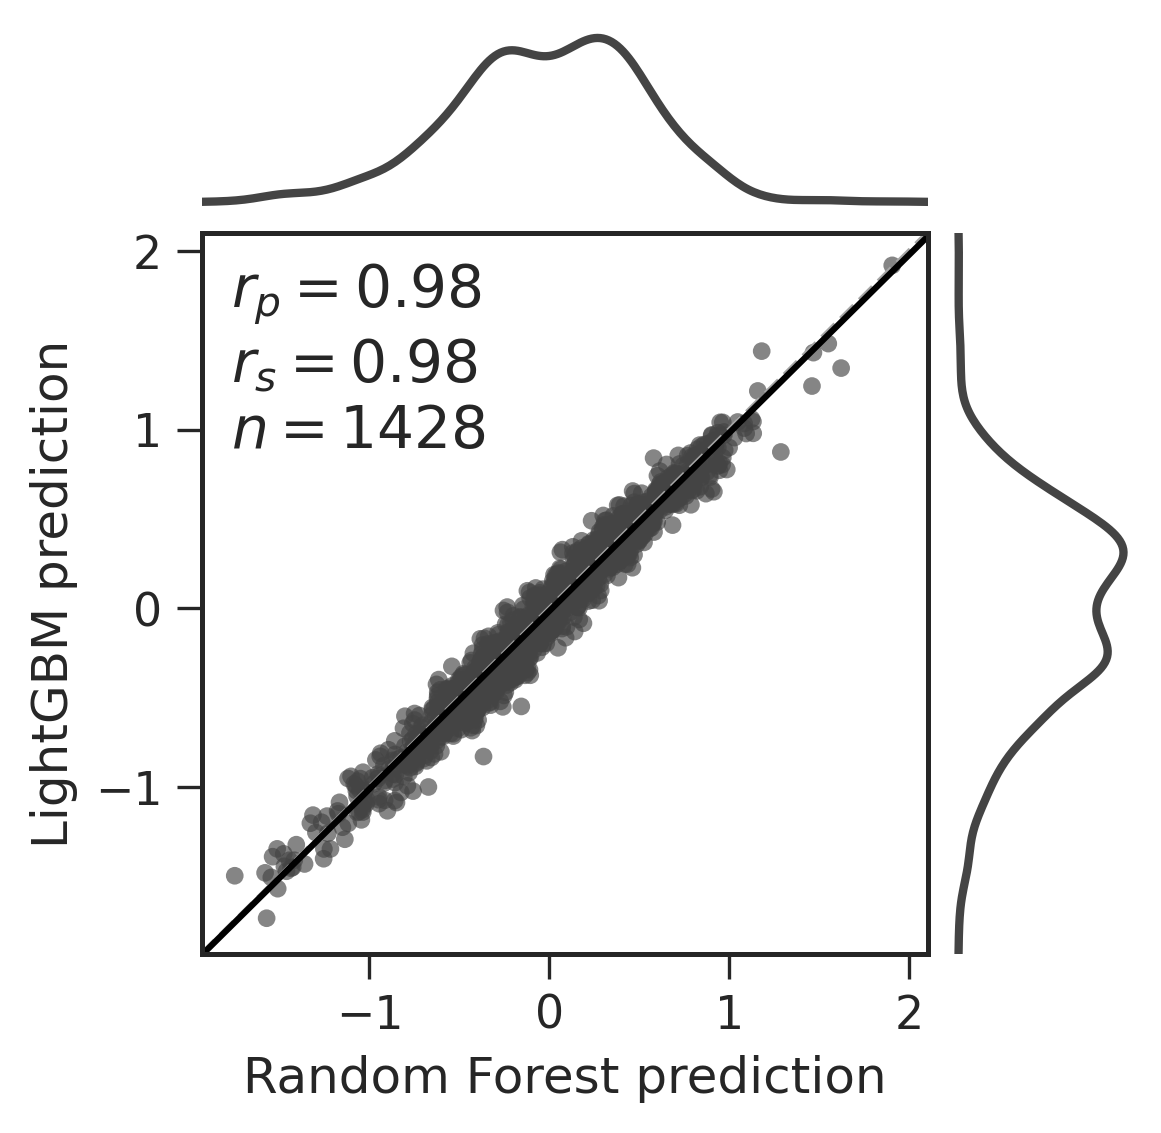

NB21 RF: (1076, 9) LGBM: (1076, 9)


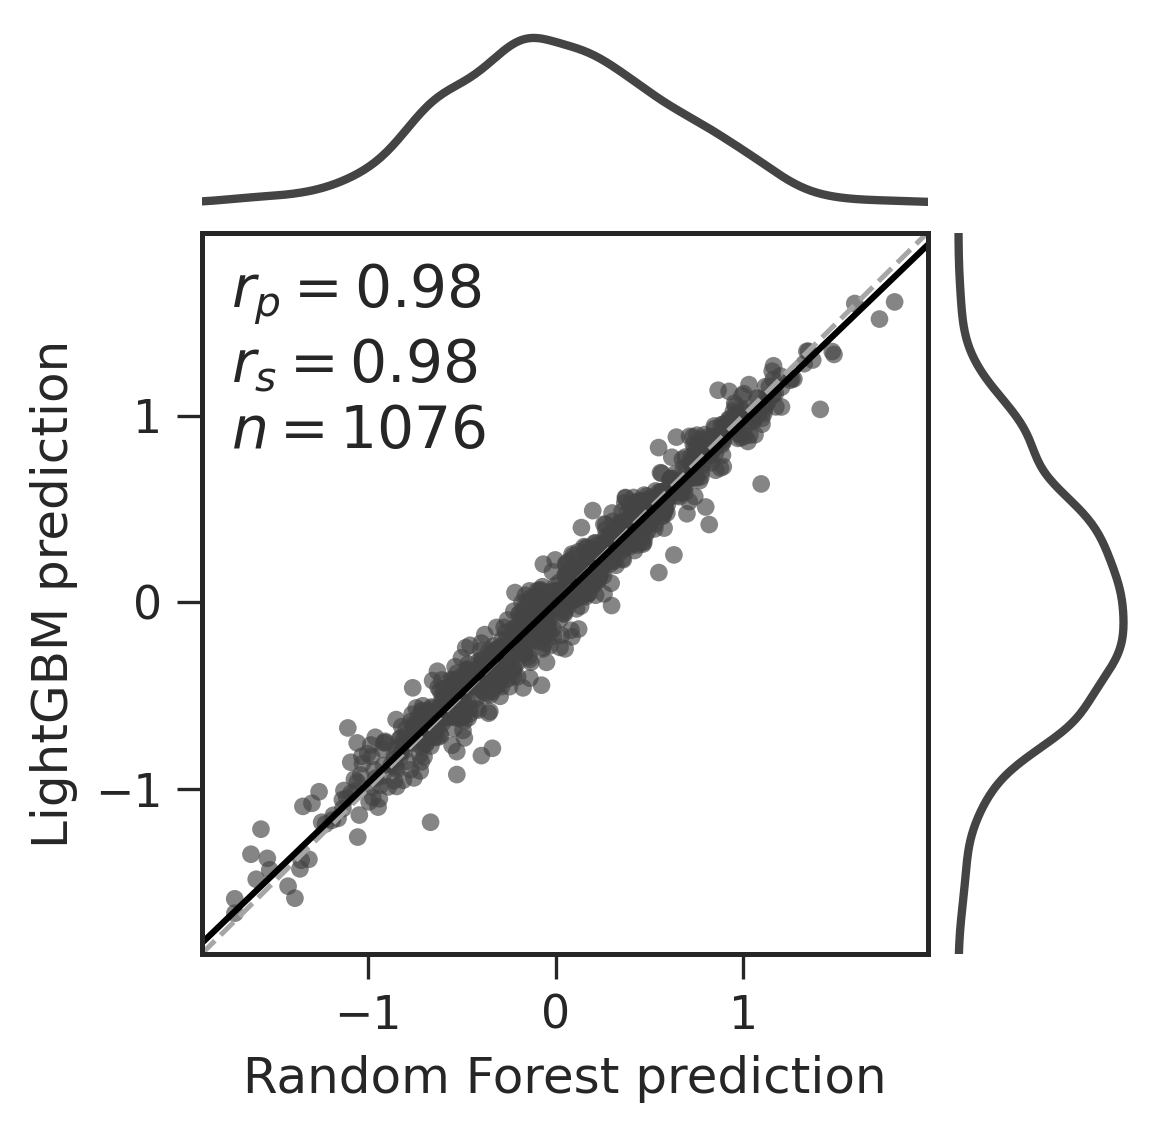

OS21 RF: (1107, 9) LGBM: (1107, 9)


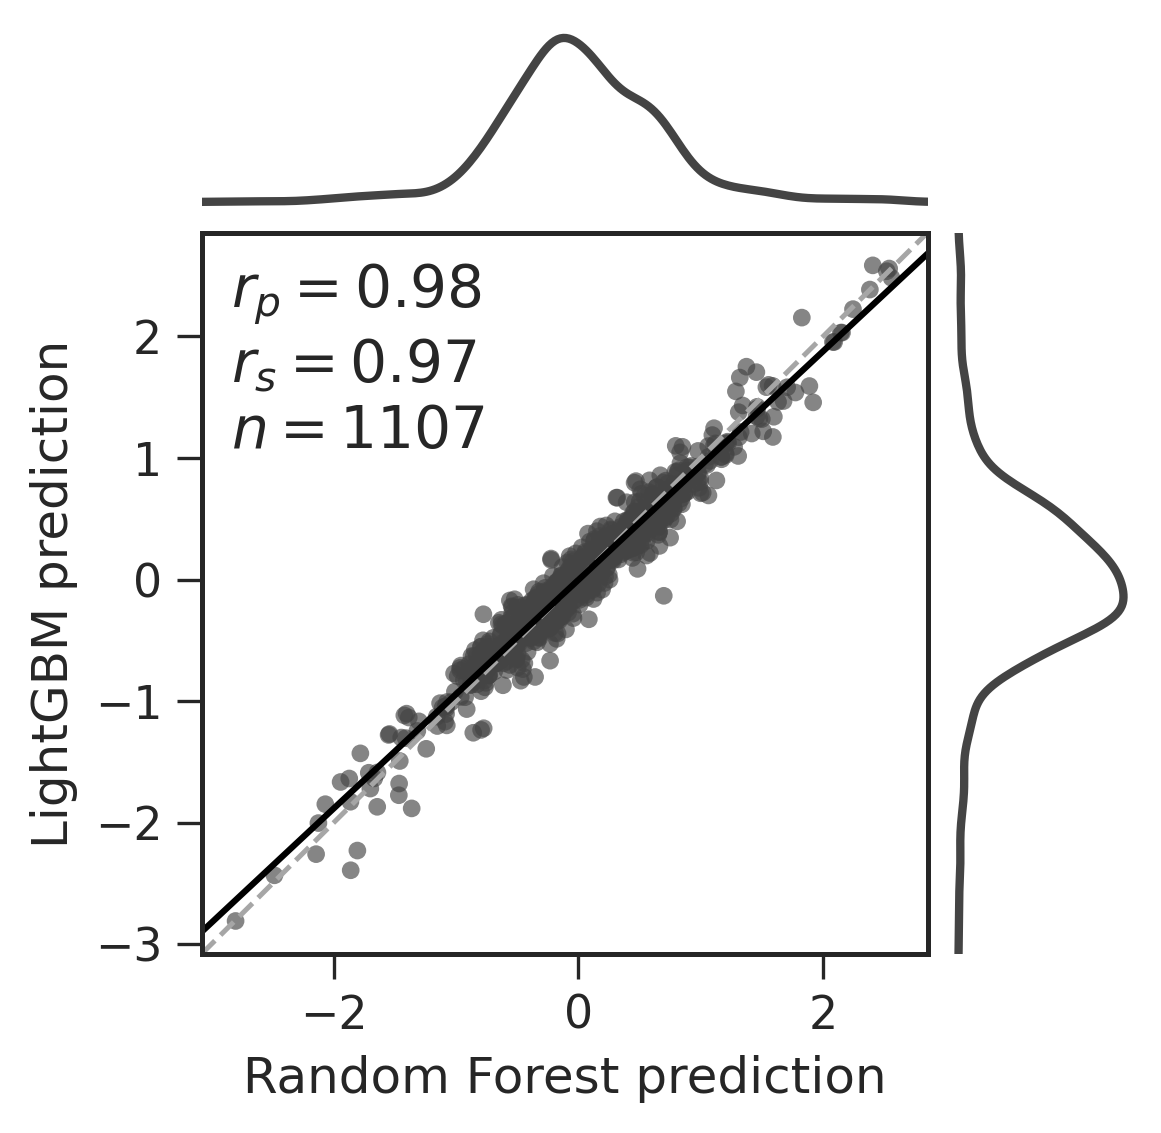

In [35]:
# ============================================
# RF vs LightGBM prediction comparison
# ============================================

for species in SPECIES_LIST:

    rf_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "RandomForest") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    lgbm_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "LightGBM") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    print(species, "RF:", rf_df.shape, "LGBM:", lgbm_df.shape)

    if rf_df.empty or lgbm_df.empty:
        print(f"{species}: missing prediction data.")
        continue

    fig, _ = joint_scatter(
        rf_df["predicted"],
        lgbm_df["predicted"],
        color="#444444",
        xlabel="Random Forest prediction",
        ylabel="LightGBM prediction",
        show_identity=True,
        show_regression=True,
        w=4,
        h=4,
    )

    plt.show()
    plt.close()

AT21 RF: (1428, 9) LGBM: (1428, 9)


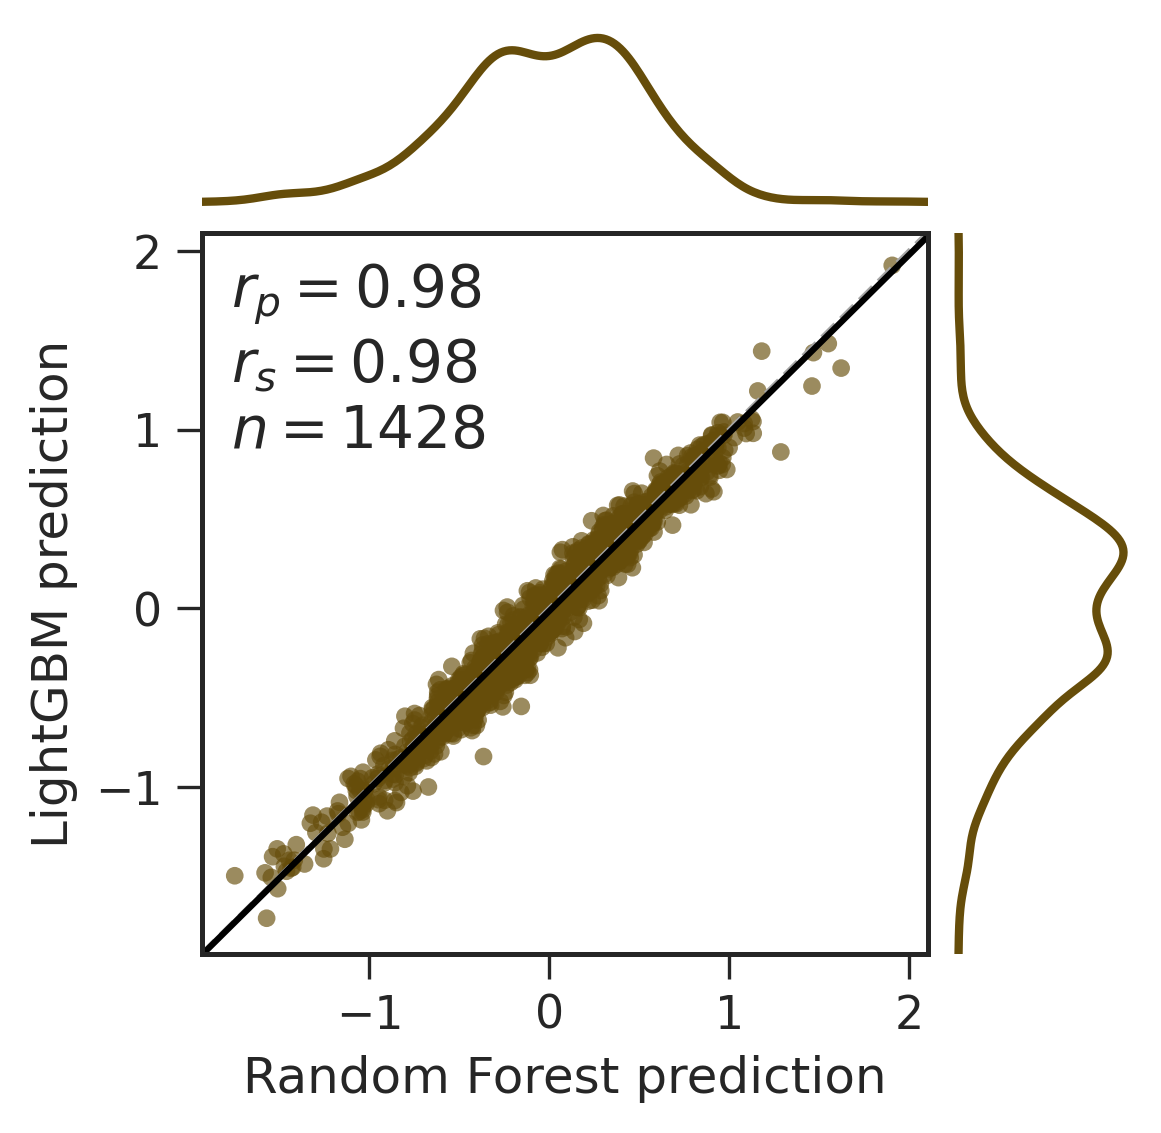

NB21 RF: (1076, 9) LGBM: (1076, 9)


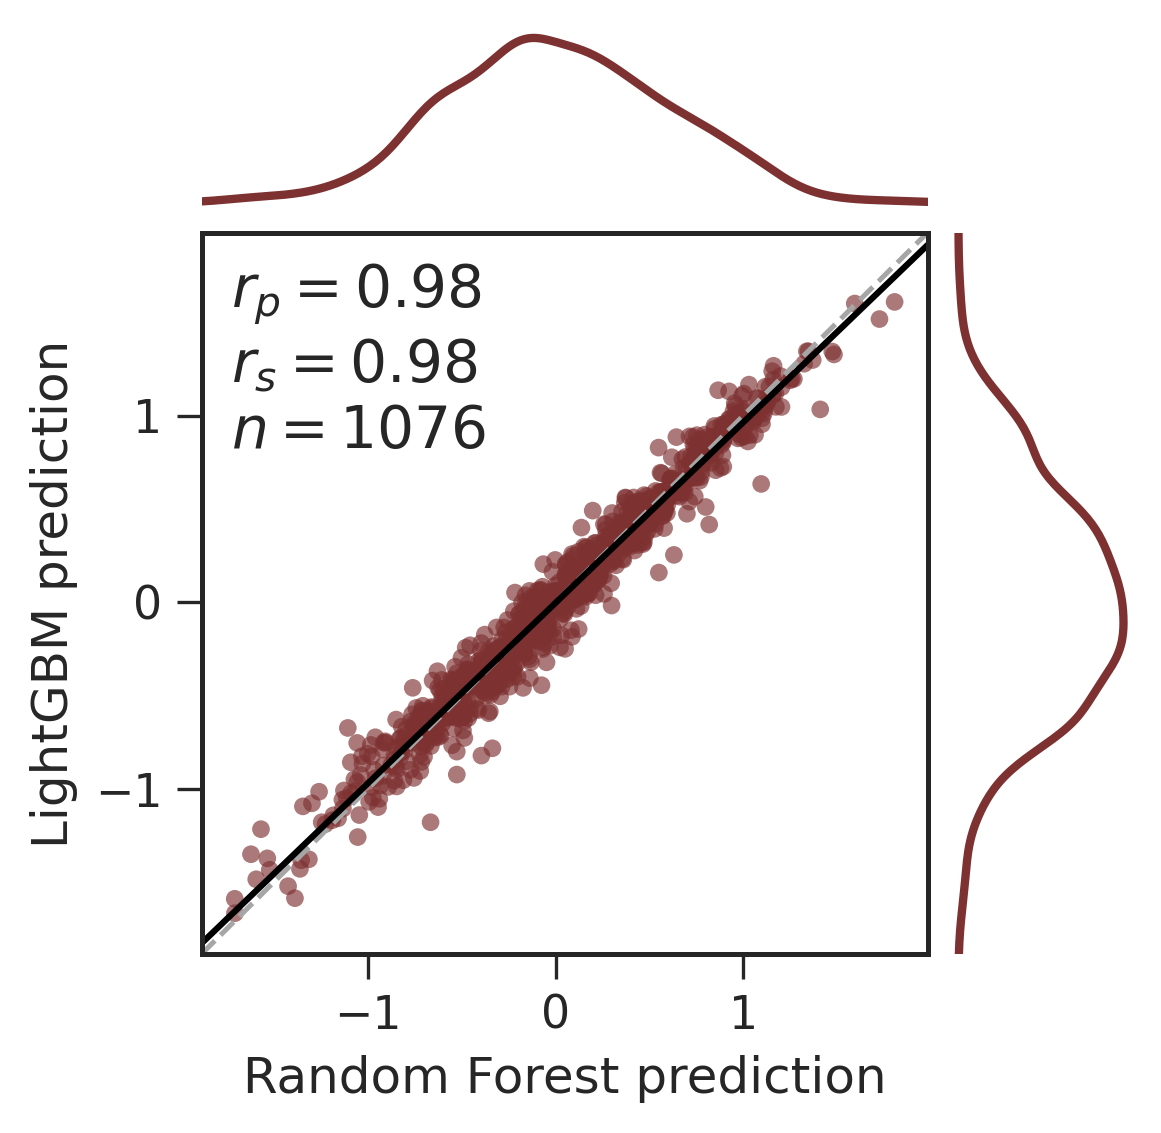

OS21 RF: (1107, 9) LGBM: (1107, 9)


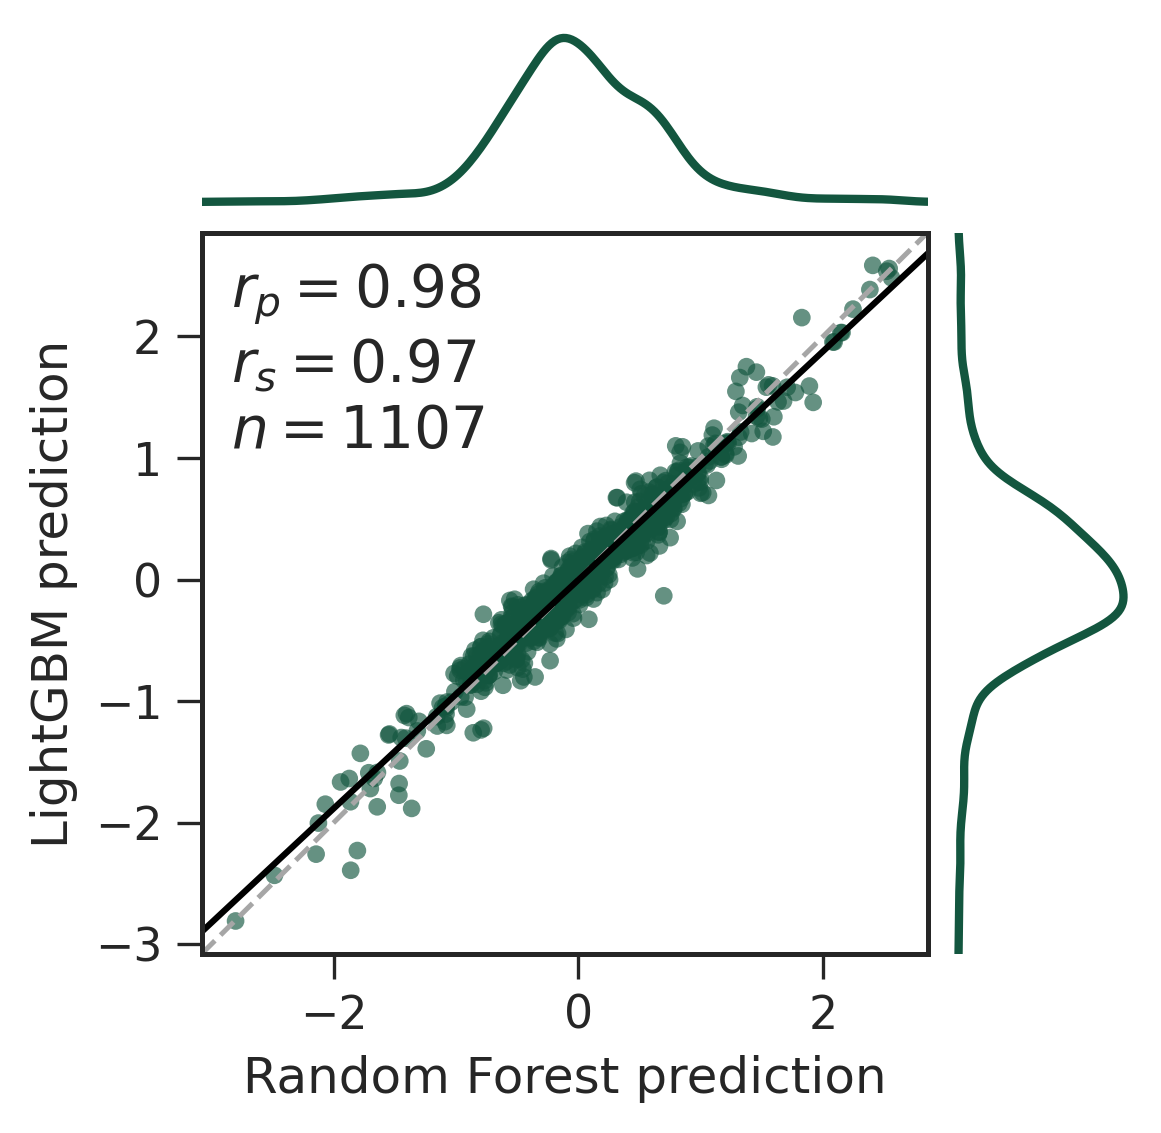

In [36]:
# ============================================
# RF vs LightGBM prediction comparison
# ============================================

for species in SPECIES_LIST:

    rf_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "RandomForest") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    lgbm_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "LightGBM") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    print(species, "RF:", rf_df.shape, "LGBM:", lgbm_df.shape)

    if rf_df.empty or lgbm_df.empty:
        print(f"{species}: missing prediction data.")
        continue

    fig, _ = joint_scatter(
        rf_df["predicted"],
        lgbm_df["predicted"],
        color=SPECIES_INFO[species]["color"],
        xlabel="Random Forest prediction",
        ylabel="LightGBM prediction",
        # title=SPECIES_INFO[species]["label"],
        show_identity=True,
        show_regression=True,
        annotate=True,
        annotate_spearman=True,
        w=4,
        h=4,
    )

    plt.show()
    plt.close()

In [37]:
# ============================================
# Prepare feature importance analysis dataframe
# ============================================

feature_df = feature_importance_df.copy()

# Keep raw importance values from saved files.
# Recompute rank here so ranking method is explicit.
feature_df["rank_dense"] = (
    feature_df
    .groupby(["species", "model"])["importance"]
    .rank(
        ascending=False,
        method="dense",
    )
    .astype(int)
)

feature_df["rank_min"] = (
    feature_df
    .groupby(["species", "model"])["importance"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

feature_df["importance_norm"] = (
    feature_df
    .groupby(["species", "model"])["importance"]
    .transform(lambda x: x / x.max())
)

feature_df = feature_df.sort_values(
    ["species", "model", "rank_dense"]
).reset_index(drop=True)

display(feature_df.head(20))

,species,model,rank,feature,importance,rank_dense,rank_min,importance_norm
0,AT21,LightGBM,1,5'UTR.CUU-freq,29.0,1,1,1.000000
1,AT21,LightGBM,2,5'UTR.C-freq,28.0,2,2,0.965517
2,AT21,LightGBM,3,5'UTR.S-freq,27.0,3,3,0.931034
3,AT21,LightGBM,4,5'UTR.U-freq,26.0,4,4,0.896552
4,AT21,LightGBM,5,5'UTR.MFE,25.0,5,5,0.862069
5,AT21,LightGBM,6,5'UTR.G-freq,24.0,6,6,0.827586
6,AT21,LightGBM,7,3'UTR.UUU-freq,24.0,6,6,0.827586
7,AT21,LightGBM,8,mRNA.AUC-freq,24.0,6,6,0.827586
8,AT21,LightGBM,9,5'UTR.A-freq,23.0,7,9,0.793103
9,AT21,LightGBM,10,3'UTR.GAU-freq,22.0,8,10,0.758621


In [38]:
# ============================================
# RF vs LightGBM feature-importance rank agreement
# ============================================

def format_pvalue(pval):
    if np.isnan(pval):
        return "NA"
    if pval < 1e-4:
        return f"{pval:.1e}"
    return f"{pval:.4f}"


def plot_feature_rank_agreement(
    feature_importance_df,
    *,
    species,
    w=4.0,
    h=4.0,
    color=None,
):
    df = feature_importance_df.copy()

    if color is None:
        color = SPECIES_INFO[species]["color"]

    rf = df[
        (df["species"] == species)
        & (df["model"] == "RandomForest")
    ][["feature", "rank"]].rename(
        columns={"rank": "RF_rank"}
    )

    lgbm = df[
        (df["species"] == species)
        & (df["model"] == "LightGBM")
    ][["feature", "rank"]].rename(
        columns={"rank": "LGBM_rank"}
    )

    rank_df = rf.merge(
        lgbm,
        on="feature",
        how="inner",
    )

    fig, ax = make_fig(w=w, h=h)

    ax.scatter(
        rank_df["RF_rank"],
        rank_df["LGBM_rank"],
        s=18,
        alpha=0.55,
        edgecolor="none",
        color=color,
    )

    max_rank = int(
        max(
            rank_df["RF_rank"].max(),
            rank_df["LGBM_rank"].max(),
        )
    )

    ax.plot(
        [0, max_rank],
        [0, max_rank],
        ls="--",
        lw=1.2,
        color="0.65",
        zorder=1,
    )

    ax.set_xlim(max_rank + 5, 0)
    ax.set_ylim(max_rank + 5, 0)

    format_axis(
        ax,
        xlabel="RF rank",
        ylabel="LightGBM rank",
        compact_ticks=(),
    )

    rho, pval = safe_spearmanr(
        rank_df["RF_rank"],
        rank_df["LGBM_rank"],
    )

    ax.text(
        0.05,
        0.95,
        rf"$\rho = {rho:.2f}$"
        + "\n"
        + rf"$P = {format_pvalue(pval)}$"
        + "\n"
        + f"$n = {len(rank_df)}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
    )

    ax.set_title(SPECIES_INFO[species]["label"])

    plt.tight_layout()
    plt.show()
    plt.close()

    return fig, rank_df

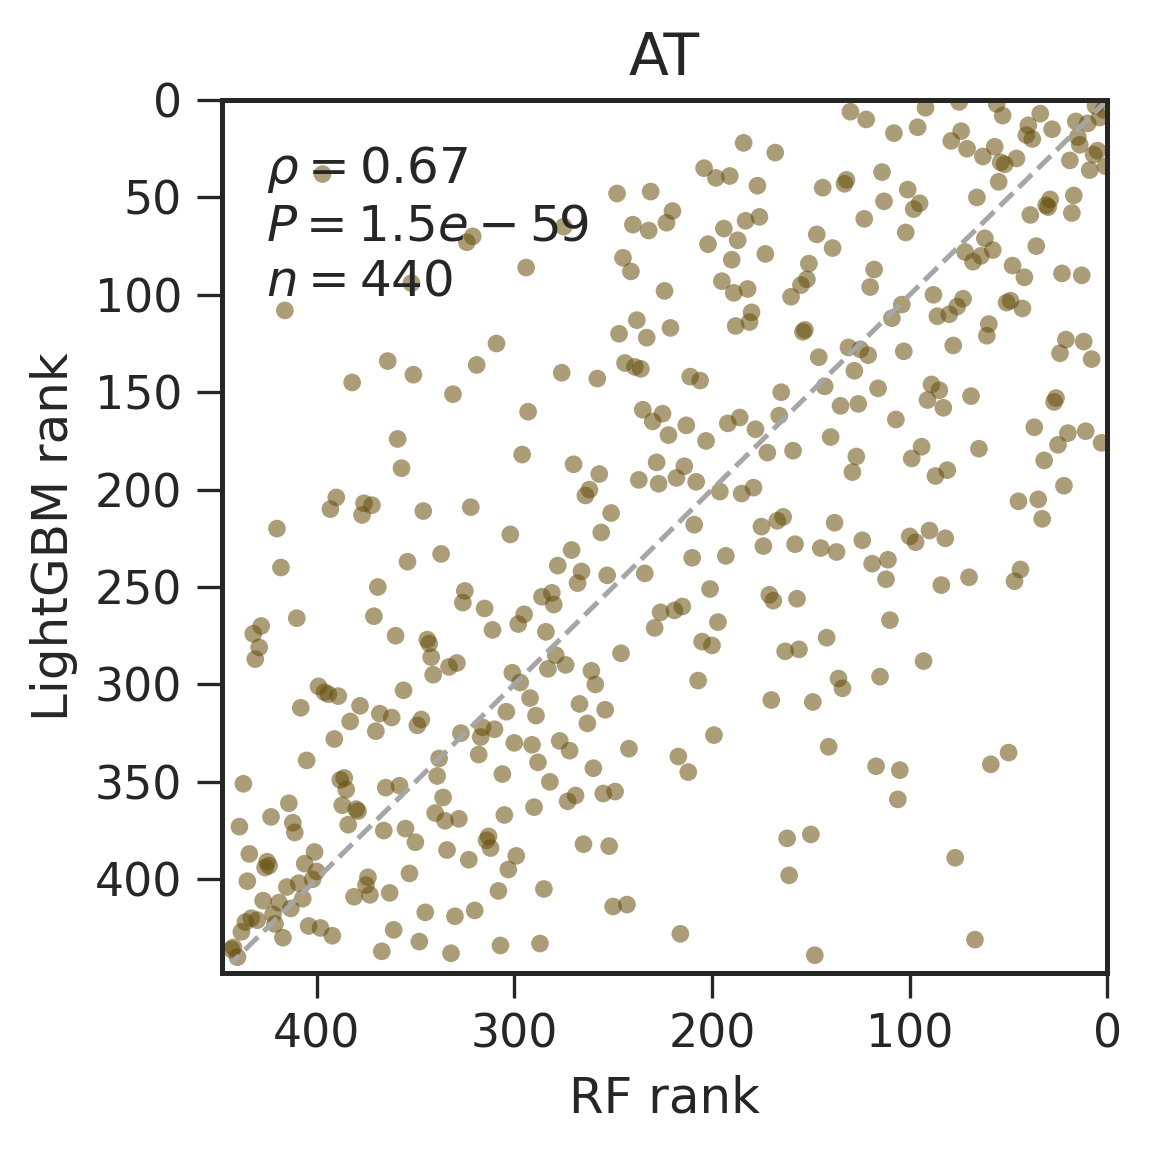

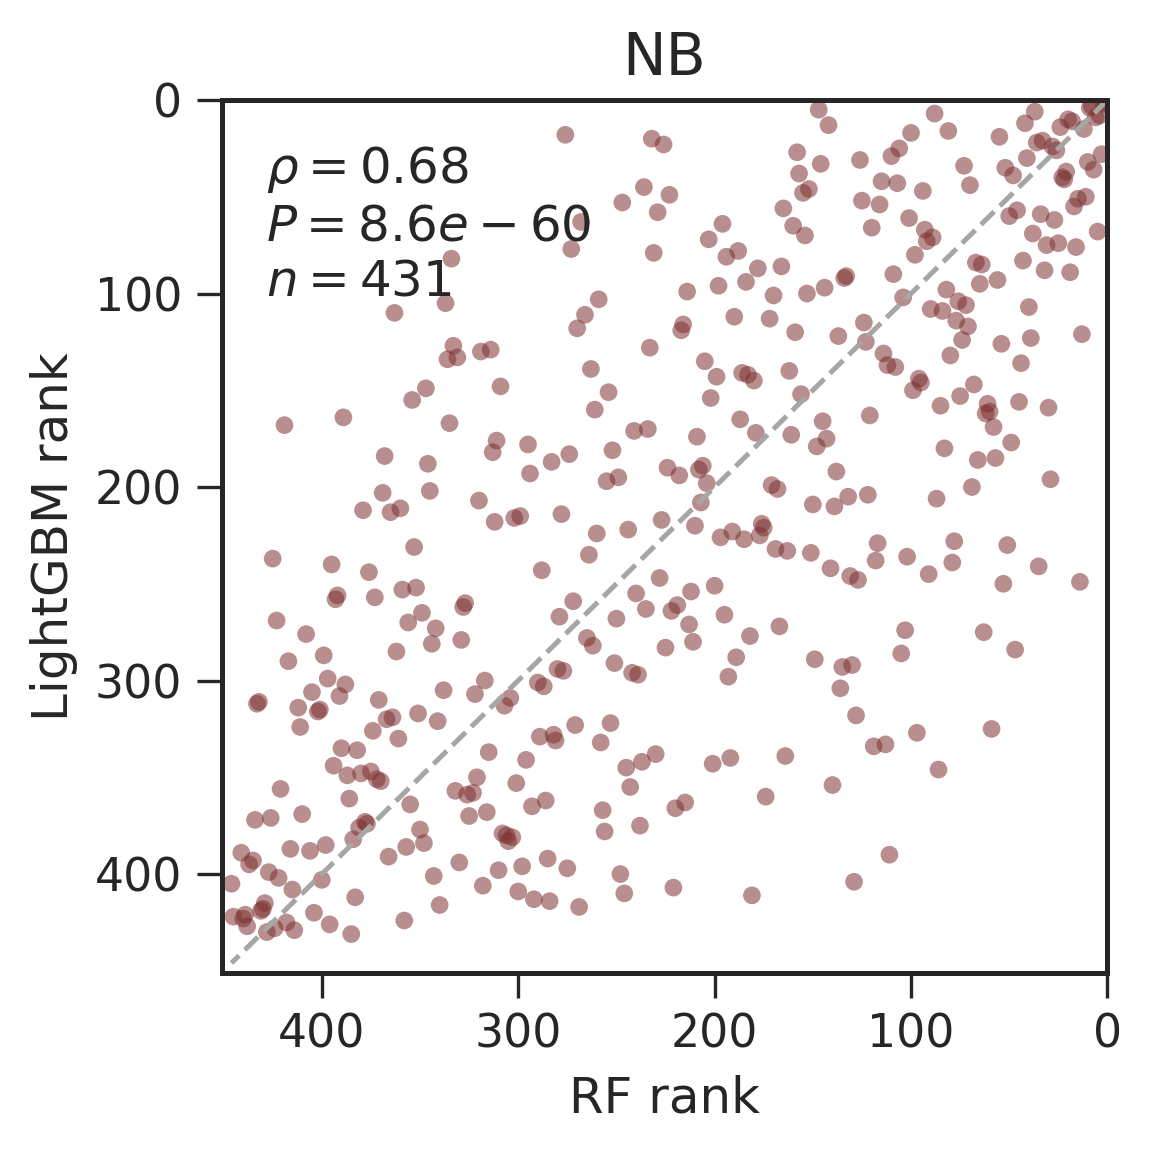

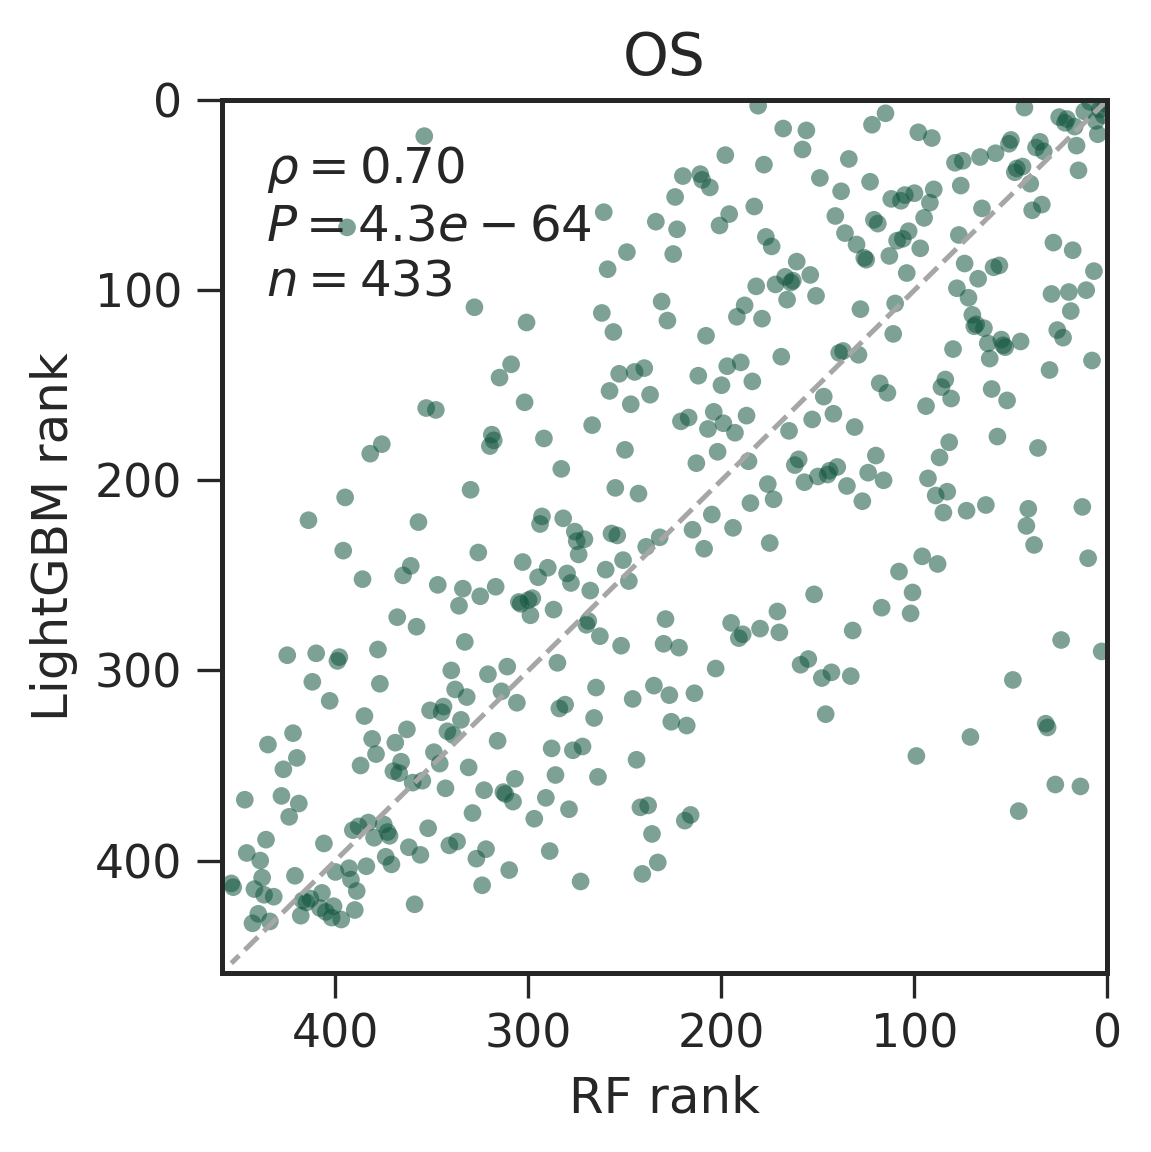

In [39]:
# ============================================
# Run feature-importance rank agreement plots
# ============================================

rank_agreement_tables = {}

for species in SPECIES_LIST:
    fig, rank_df = plot_feature_rank_agreement(
        feature_df,
        species=species,
        w=4.0,
        h=4.0,
    )

    rank_agreement_tables[species] = rank_df

In [40]:
# ============================================
# Transform feature importance
# ============================================

from sklearn.preprocessing import PowerTransformer

feature_norm_df = feature_df.copy()

feature_norm_df["importance_yj"] = np.nan
feature_norm_df["importance_z"] = np.nan

for (species, model), idx in feature_norm_df.groupby(
    ["species", "model"]
).groups.items():

    values = feature_norm_df.loc[idx, "importance"].to_numpy().reshape(-1, 1)

    pt = PowerTransformer(
        method="yeo-johnson",
        standardize=False,
    )

    yj = pt.fit_transform(values).ravel()

    z = (yj - yj.mean()) / yj.std(ddof=0)

    feature_norm_df.loc[idx, "importance_yj"] = yj
    feature_norm_df.loc[idx, "importance_z"] = z

display(feature_norm_df.head())

,species,model,rank,feature,importance,rank_dense,rank_min,importance_norm,importance_yj,importance_z
0,AT21,LightGBM,1,5'UTR.CUU-freq,29.0,1,1,1.000000,6.027249,2.711993
1,AT21,LightGBM,2,5'UTR.C-freq,28.0,2,2,0.965517,5.930607,2.623004
2,AT21,LightGBM,3,5'UTR.S-freq,27.0,3,3,0.931034,5.831635,2.531869
3,AT21,LightGBM,4,5'UTR.U-freq,26.0,4,4,0.896552,5.730192,2.438458
4,AT21,LightGBM,5,5'UTR.MFE,25.0,5,5,0.862069,5.626120,2.342627


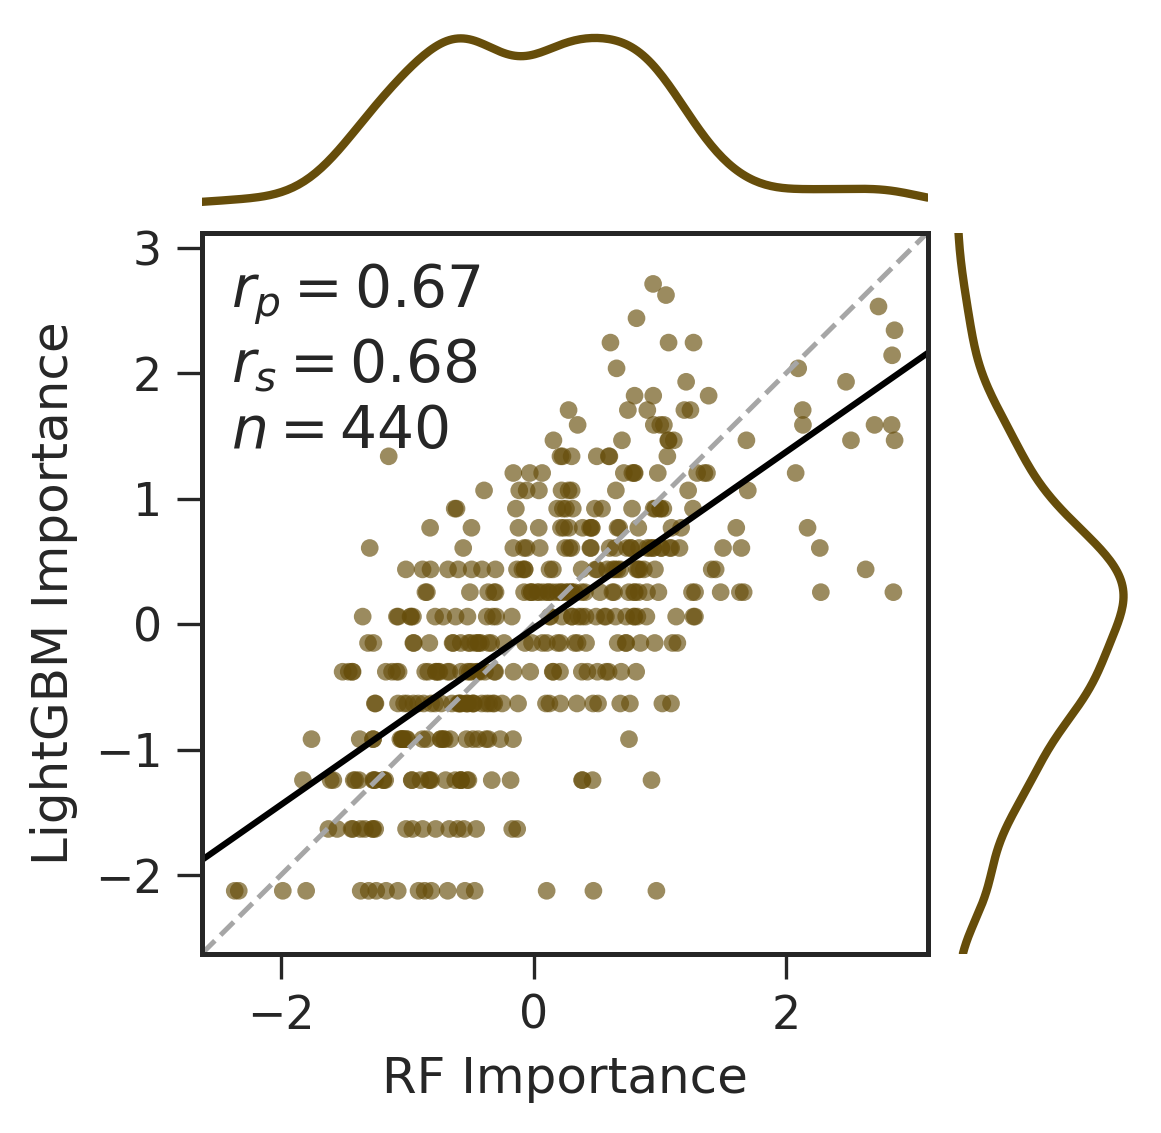

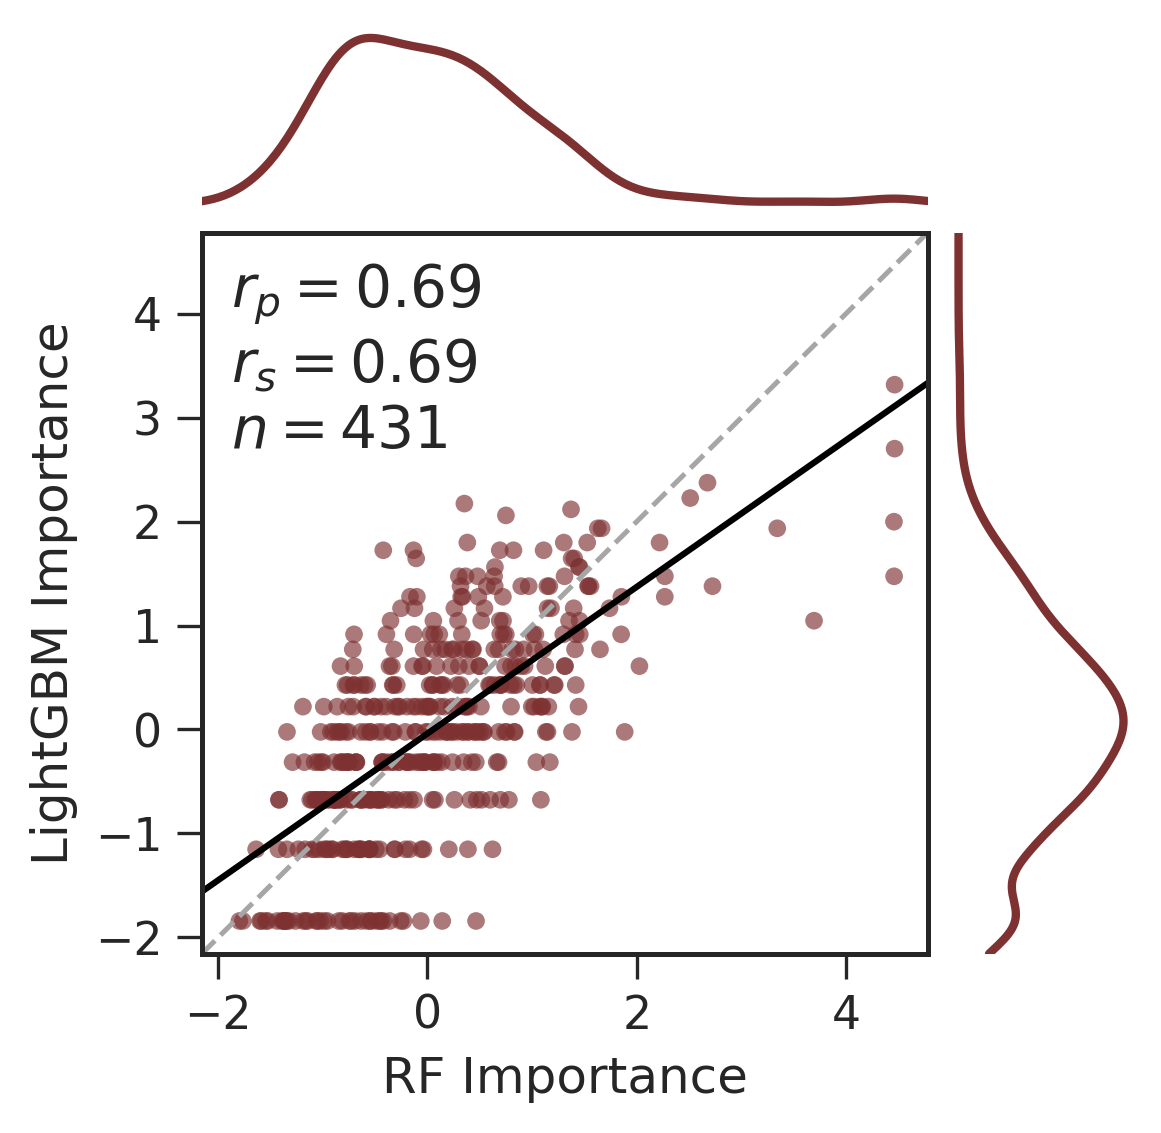

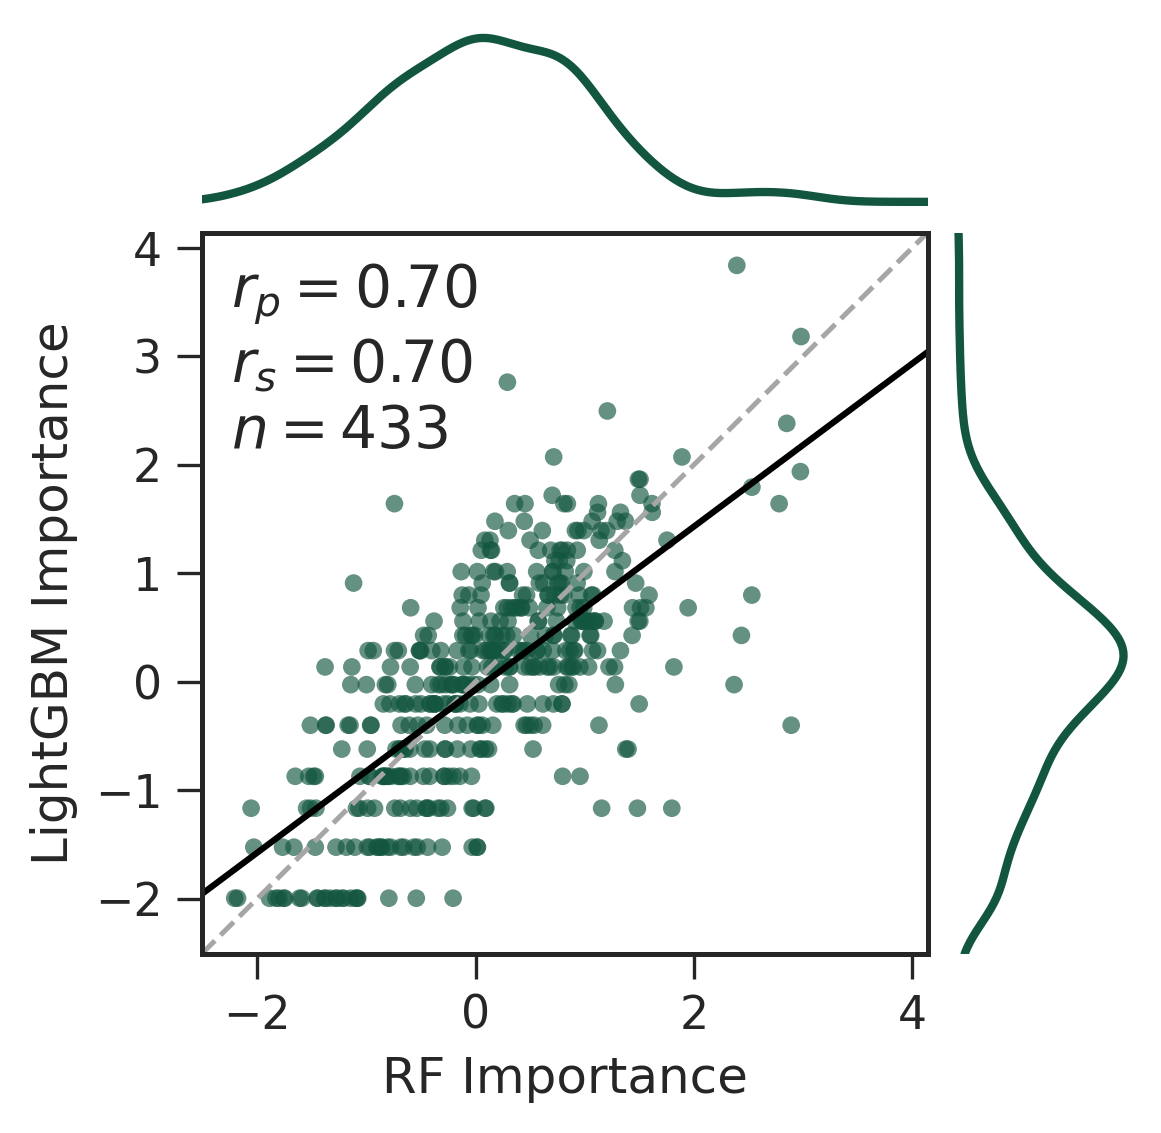

In [42]:
# ============================================
# RF vs LightGBM normalized importance
# ============================================

for species in SPECIES_LIST:

    rf = (
        feature_norm_df[
            (feature_norm_df["species"] == species)
            & (feature_norm_df["model"] == "RandomForest")
        ][["feature", "importance_z"]]
        .rename(columns={"importance_z": "RF"})
    )

    lgbm = (
        feature_norm_df[
            (feature_norm_df["species"] == species)
            & (feature_norm_df["model"] == "LightGBM")
        ][["feature", "importance_z"]]
        .rename(columns={"importance_z": "LightGBM"})
    )

    plot_df = rf.merge(
        lgbm,
        on="feature",
        how="inner",
    )

    fig, _ = joint_scatter(
        plot_df["RF"],
        plot_df["LightGBM"],
        color=SPECIES_INFO[species]["color"],
        xlabel="RF Importance",
        ylabel="LightGBM Importance",
        # title=SPECIES_INFO[species]["label"],
        show_identity=True,
        show_regression=True,
        annotate=True,
        annotate_spearman=True,
        w=4,
        h=4,
    )

    plt.show()
    plt.close()

In [43]:
# ============================================
# Load all species CV group-combination files
# ============================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

MODEL_KEY = "lgbm"   # change to "rf" later
MODEL_DIR = Path("../results") / MODEL_KEY

SPECIES_LIST = ["AT21", "NB21", "OS21"]

SPECIES_INFO = {
    "AT21": {"label": "Arabidopsis", "color": "#664D0AFF"},
    "NB21": {"label": "N. benthamiana", "color": "#8C2D04"},
    "OS21": {"label": "O. sativa", "color": "#13563f"},
}


def load_group_cv_files(group_kind):
    fold_list = []
    meta_list = []

    for species in SPECIES_LIST:
        fold_file = MODEL_DIR / f"{species}.{MODEL_KEY}.cv_by_{group_kind}_folds.tsv"
        meta_file = MODEL_DIR / f"{species}.{MODEL_KEY}.{group_kind}_group_metadata.tsv"

        fold_list.append(pd.read_csv(fold_file, sep="\t"))
        meta_list.append(pd.read_csv(meta_file, sep="\t"))

    fold_all = pd.concat(fold_list, ignore_index=True)
    meta_all = pd.concat(meta_list, ignore_index=True)

    return fold_all, meta_all


cv_region_fold_all_df, region_group_all_df = load_group_cv_files("region")
cv_type_fold_all_df, feature_type_group_all_df = load_group_cv_files("feature_type")

display(cv_region_fold_all_df.head())
display(region_group_all_df.head())

print(cv_region_fold_all_df.shape)
print(region_group_all_df.shape)

,species,model,combo,combo_id,fold,R2_CV,n_sets,n_features,in_UTR5,in_CDS,in_UTR3,in_mRNA
0,AT21,LightGBM,CDS,CDS,0,0.232384,1,190,0,1,0,0
1,AT21,LightGBM,CDS,CDS,1,0.138671,1,190,0,1,0,0
2,AT21,LightGBM,CDS,CDS,2,0.196297,1,190,0,1,0,0
3,AT21,LightGBM,CDS,CDS,3,0.165558,1,190,0,1,0,0
4,AT21,LightGBM,CDS,CDS,4,0.217468,1,190,0,1,0,0


,species,model,group_kind,group_name,group_id,n_features_single,feature_list
0,AT21,LightGBM,region,5'UTR,UTR5,93,5'UTR.Length;5'UTR.A-freq;5'UTR.U-freq;5'UTR.G...
1,AT21,LightGBM,region,CDS,CDS,190,CDS.Length;CDS.A-freq;CDS.U-freq;CDS.G-freq;CD...
2,AT21,LightGBM,region,3'UTR,UTR3,92,3'UTR.Length;3'UTR.A-freq;3'UTR.U-freq;3'UTR.G...
3,AT21,LightGBM,region,mRNA,mRNA,89,mRNA.Length;mRNA.A-freq;mRNA.U-freq;mRNA.G-fre...
4,NB21,LightGBM,region,5'UTR,UTR5,93,5'UTR.Length;5'UTR.A-freq;5'UTR.U-freq;5'UTR.G...


(450, 12)
(12, 7)


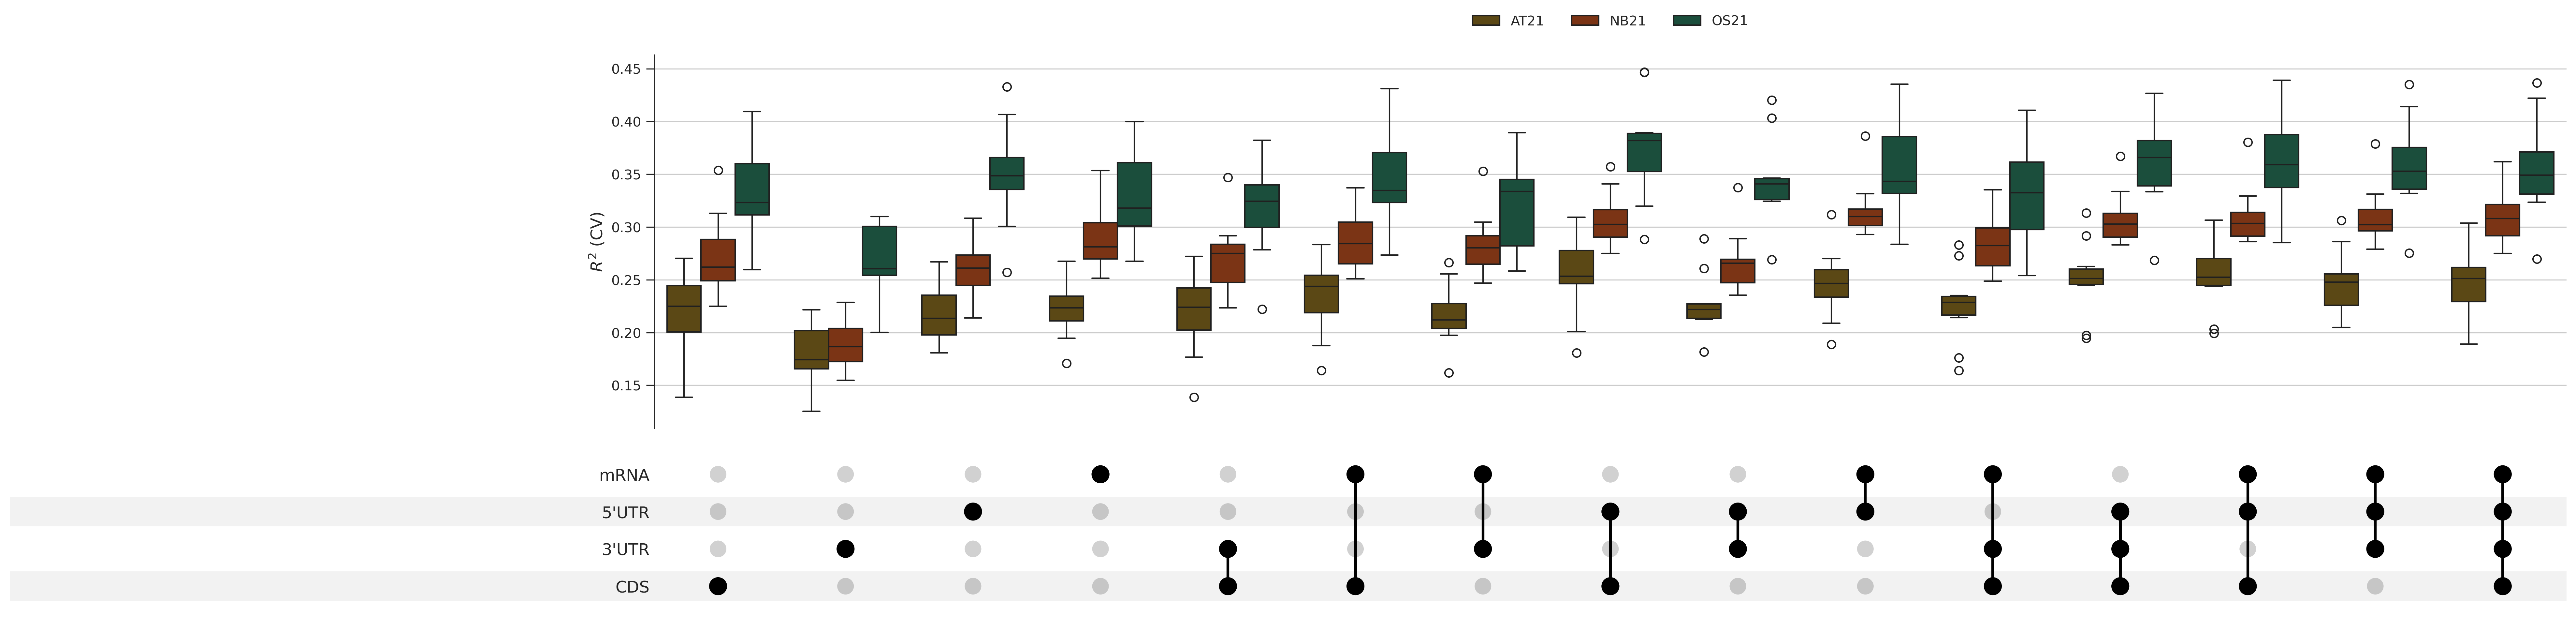

In [113]:
# ============================================
# 3-species UpSet boxplot
# ============================================

from upsetplot import UpSet, from_memberships


def plot_upset_species_boxplot(
    fold_all_df,
    group_all_df,
    *,
    fig_w=11,
    fig_h=5.5,
    dpi=300,
):
    df = fold_all_df.copy()

    group_df = (
        group_all_df
        .groupby("group_id", as_index=False)
        .first()
    )

    group_ids = group_df["group_id"].tolist()

    membership_cols = [
        f"in_{gid}"
        for gid in group_ids
        if f"in_{gid}" in df.columns
    ]

    for c in membership_cols:
        df[c] = df[c].astype(bool)

    memberships = []

    for _, row in df.iterrows():
        memberships.append([
            c.replace("in_", "")
            for c in membership_cols
            if row[c]
        ])

    upset_df = from_memberships(
        memberships,
        data=df[["R2_CV", "species"]].reset_index(drop=True),
    )

    up = UpSet(
        upset_df,
        show_counts=False,
        subset_size="count",
        sort_categories_by=None,
        sort_by=None,
        facecolor="black",
        element_size=35,          
        intersection_plot_elements=0,
    )

    up.add_catplot(
        value="R2_CV",
        kind="box",
        hue="species",
        palette={
            "AT21": "#664D0A",
            "NB21": "#8C2D04",
            "OS21": "#13563f",
        },
    )

    fig = plt.figure(
        figsize=(fig_w, fig_h),
        dpi=dpi,
        facecolor="white",
    )

    axes = up.plot(fig=fig)

    # -----------------------------------
    # Remove Set Size panel completely
    # -----------------------------------

    if "totals" in axes:
        axes["totals"].remove()

    # -----------------------------------
    # Matrix labels
    # -----------------------------------

    if "matrix" in axes:

        ax_matrix = axes["matrix"]

        id_to_name = dict(
            zip(
                group_df["group_id"],
                group_df["group_name"],
            )
        )

        labels = [
            id_to_name.get(
                t.get_text(),
                t.get_text(),
            )
            for t in ax_matrix.get_yticklabels()
        ]

        ax_matrix.set_yticklabels(
            labels,
            fontsize=12,
        )

        ax_matrix.spines["left"].set_visible(False)
        ax_matrix.spines["right"].set_visible(False)

    # -----------------------------------
    # Boxplot panel
    # -----------------------------------

    box_ax = None

    for ax in fig.axes:

        if ax.get_ylabel() == "R2_CV":

            box_ax = ax

            ax.set_ylabel(
                r"$R^2$ (CV)",
                fontsize=12,
            )

            ax.tick_params(
                axis="both",
                labelsize=10,
            )

            handles, labels = ax.get_legend_handles_labels()

            if len(handles):

                old = ax.get_legend()
                if old is not None:
                    old.remove()

                ax.legend(
                    handles,
                    labels,
                    loc="lower center",
                    bbox_to_anchor=(0.5, 1.04),
                    ncol=3,
                    frameon=False,
                    fontsize=10,
                    title_fontsize=11,
                )

    # -----------------------------------
    # Figure proportions
    # -----------------------------------

    fig.subplots_adjust(
        left=0.29,
        right=2.98,
        top=0.92,
        bottom=0.05,
    )

    # Slightly enlarge boxplot panel after UpSet has drawn it
    if box_ax is not None:
        pos = box_ax.get_position()

        box_ax.set_position([
            pos.x0,
            pos.y0 + 0.005,
            pos.width,
            pos.height * 3.35,
        ])

    plt.show()

    return fig, axes

fig_region_all, axes_region_all = plot_upset_species_boxplot(
    cv_region_fold_all_df,
    region_group_all_df,
    fig_w=15,
    fig_h=5,
)

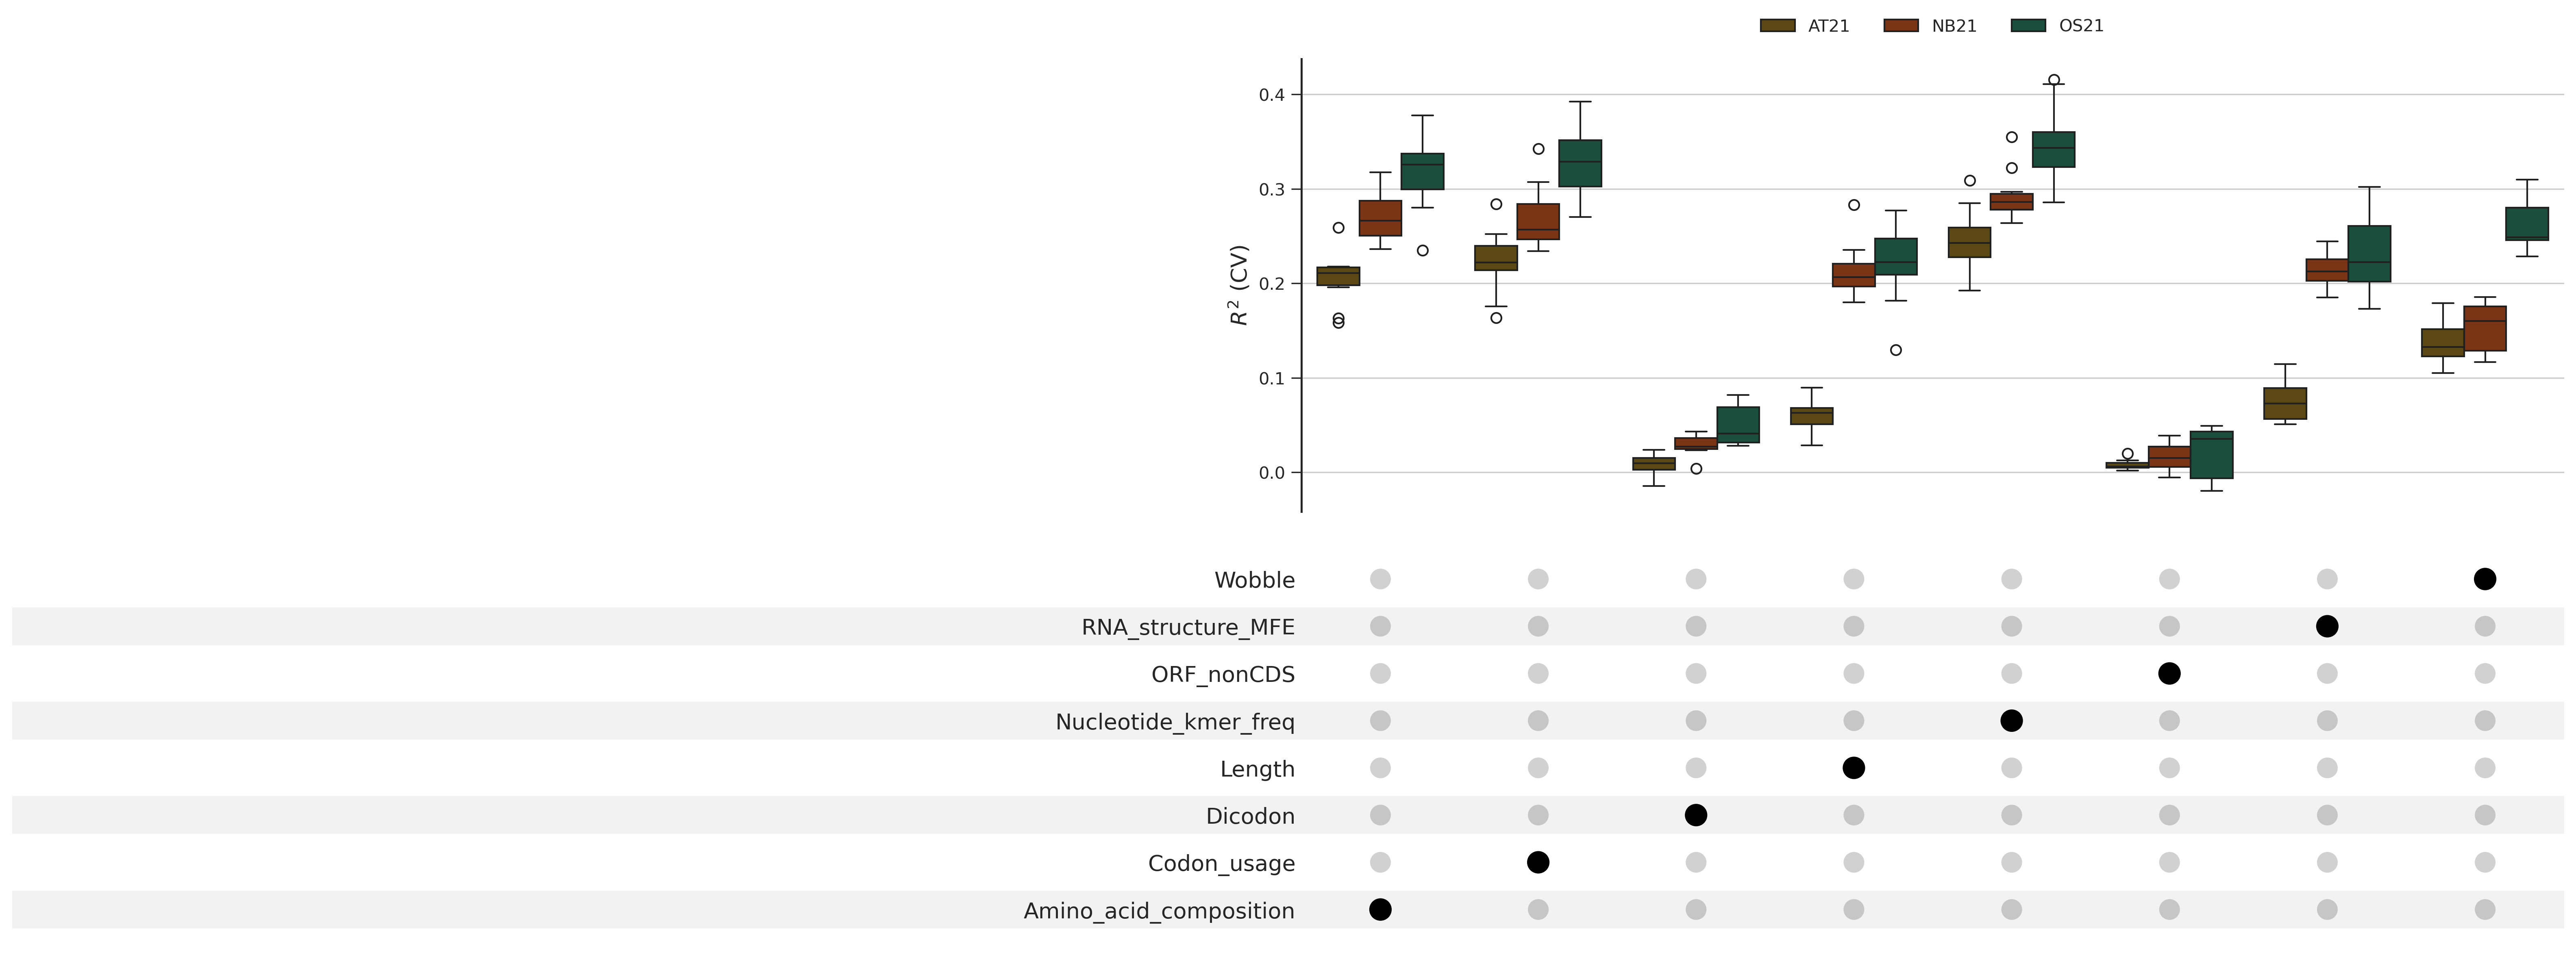

In [114]:
# ============================================
# 3-species UpSet boxplot
# Feature type (single feature groups)
# ============================================

from upsetplot import UpSet, from_memberships


def plot_upset_species_boxplot_feature_type(
    fold_all_df,
    group_all_df,
    *,
    fig_w=9,
    fig_h=6,
    dpi=300,
):

    df = fold_all_df.copy()

    group_df = (
        group_all_df
        .groupby("group_id", as_index=False)
        .first()
    )

    group_ids = group_df["group_id"].tolist()

    membership_cols = [
        f"in_{gid}"
        for gid in group_ids
        if f"in_{gid}" in df.columns
    ]

    for c in membership_cols:
        df[c] = df[c].astype(bool)

    memberships = []

    for _, row in df.iterrows():
        memberships.append([
            c.replace("in_", "")
            for c in membership_cols
            if row[c]
        ])

    upset_df = from_memberships(
        memberships,
        data=df[["R2_CV", "species"]].reset_index(drop=True),
    )

    up = UpSet(
        upset_df,
        show_counts=False,
        subset_size="count",
        sort_categories_by=None,
        sort_by=None,
        facecolor="black",
        element_size=35,
        intersection_plot_elements=0,
    )

    up.add_catplot(
        value="R2_CV",
        kind="box",
        hue="species",
        palette={
            "AT21": "#664D0A",
            "NB21": "#8C2D04",
            "OS21": "#13563f",
        },
    )

    fig = plt.figure(
        figsize=(fig_w, fig_h),
        dpi=dpi,
        facecolor="white",
    )

    axes = up.plot(fig=fig)

    # -----------------------------------
    # Remove Set Size panel
    # -----------------------------------

    if "totals" in axes:
        axes["totals"].remove()

    # -----------------------------------
    # Matrix labels
    # -----------------------------------

    if "matrix" in axes:

        ax_matrix = axes["matrix"]

        id_to_name = dict(
            zip(
                group_df["group_id"],
                group_df["group_name"],
            )
        )

        labels = [
            id_to_name.get(
                t.get_text(),
                t.get_text(),
            )
            for t in ax_matrix.get_yticklabels()
        ]

        ax_matrix.set_yticklabels(
            labels,
            fontsize=13,
        )

        ax_matrix.spines["left"].set_visible(False)
        ax_matrix.spines["right"].set_visible(False)

    # -----------------------------------
    # Boxplot axis
    # -----------------------------------

    box_ax = None

    for ax in fig.axes:

        if ax.get_ylabel() == "R2_CV":

            box_ax = ax

            ax.set_ylabel(
                r"$R^2$ (CV)",
                fontsize=13,
            )

            ax.tick_params(
                axis="both",
                labelsize=10,
            )

            handles, labels = ax.get_legend_handles_labels()

            if len(handles):

                old = ax.get_legend()
                if old is not None:
                    old.remove()

                ax.legend(
                    handles,
                    labels,
                    loc="lower center",
                    bbox_to_anchor=(0.5, 1.02),
                    ncol=3,
                    frameon=False,
                    fontsize=10,
                )

    # -----------------------------------
    # Layout
    # -----------------------------------

    # fig.subplots_adjust(
    #     left=0.08,
    #     right=0.98,
    #     top=0.88,
    #     bottom=0.08,
    # )
    fig.subplots_adjust(
        left=0.29,
        right=2.98,
        top=0.92,
        bottom=0.05,
    )
    # -----------------------------------
    # Enlarge boxplot panel
    # -----------------------------------

    if box_ax is not None:

        pos = box_ax.get_position()

        box_ax.set_position([
            pos.x0,
            pos.y0 + 0.005,
            pos.width,
            pos.height * 3.35,
        ])

    plt.show()

    return fig, axes

cv_type_fold_single_all_df = (
    cv_type_fold_all_df
    .query("n_sets == 1")
    .copy()
)

fig_type_all, axes_type_all = plot_upset_species_boxplot_feature_type(
    cv_type_fold_single_all_df,
    feature_type_group_all_df,
    fig_w=25,
    fig_h=7.5,
)